## Import Libraries

RW joint id=2, qvel addr=7
GW actuator id=0, RW actuator id=1
Simulating 4.0s (2000 steps)...
  Peak RPM: +4685.3,  Final RPM: -4685.2
Video saved: rw_spinup_test.mp4  (250 frames)


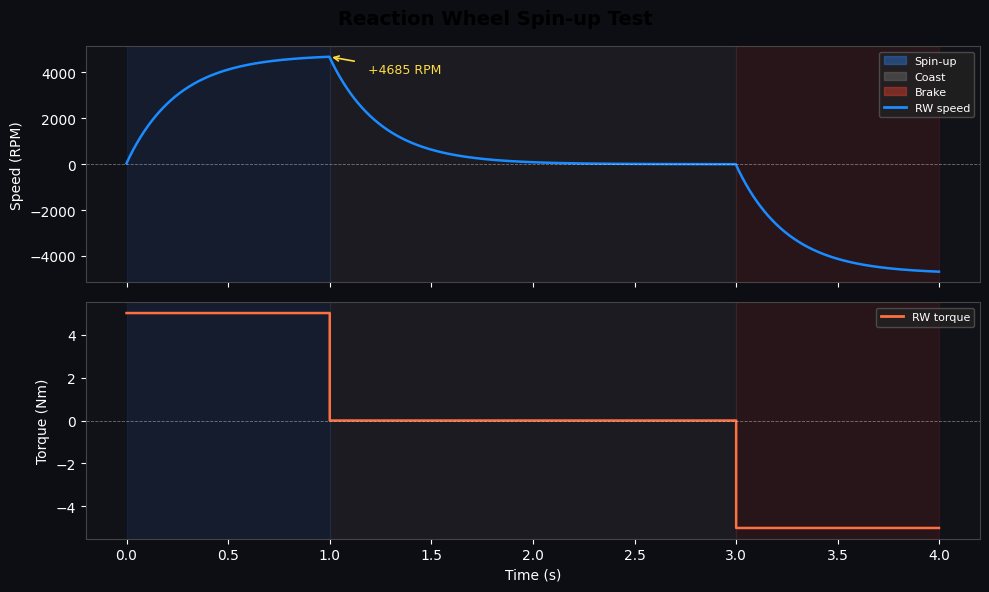

Plot saved: rw_spinup_plot.png


In [1]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import imageio
from PIL import Image as PILImage, ImageDraw, ImageFont

# ── Model setup ───────────────────────────────────────────────────────────────
XML_PATH = "segway_2.xml"
model    = mujoco.MjModel.from_xml_path(XML_PATH)
data     = mujoco.MjData(model)
dt       = model.opt.timestep

# Joint lookup (do once)
rw_joint_id  = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "joint_reaction_wheel")
rw_qvel_addr = model.jnt_dofadr[rw_joint_id]
# Also grab ground wheel index for actuator indexing
gw_motor_id  = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "wheels_motor")
rw_motor_id  = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "reaction_wheel_motor")
print(f"RW joint id={rw_joint_id}, qvel addr={rw_qvel_addr}")
print(f"GW actuator id={gw_motor_id}, RW actuator id={rw_motor_id}")

# ── Phase schedule ────────────────────────────────────────────────────────────
#   Phase 0: spin-up   — full positive torque for 1 s
#   Phase 1: coast     — zero torque for 2 s
#   Phase 2: brake     — full negative torque for 1 s
SPIN_TORQUE  =  5.0   # Nm  (ctrlrange max)
BRAKE_TORQUE = -5.0   # Nm

phase_schedule = [
    ("Spin-up",  1.0, SPIN_TORQUE),
    ("Coast",    2.0, 0.0),
    ("Brake",    1.0, BRAKE_TORQUE),
]
total_time = sum(d for _, d, _ in phase_schedule)
total_steps = int(total_time / dt)

# ── Camera ────────────────────────────────────────────────────────────────────
renderer = mujoco.Renderer(model, height=480, width=640)
cam = mujoco.MjvCamera()
cam.type      = mujoco.mjtCamera.mjCAMERA_FREE
cam.lookat    = np.array([0.0, 0.0, 0.3])
cam.distance  = 1.8
cam.azimuth   = 45
cam.elevation = -20

# ── Reset to upright ──────────────────────────────────────────────────────────
mujoco.mj_resetData(model, data)
data.qpos[2]  = 0.075    # z height (wheel radius)
data.qpos[3:7] = [1, 0, 0, 0]   # upright quaternion
data.qvel[:]   = 0.0
# Lock the ground wheel to stop the robot driving off
# (keep wheel motor at 0; we only actuate the reaction wheel)
mujoco.mj_forward(model, data)

# ── Simulation loop ───────────────────────────────────────────────────────────
times, rpms, torques_log, phases_log = [], [], [], []
frames = []
BASE_FPS  = 60
skip      = max(1, int(round(1.0 / (BASE_FPS * dt))))  # render every n-th sim step

def get_phase(t):
    elapsed = 0.0
    for name, duration, torque in phase_schedule:
        if t < elapsed + duration:
            return name, torque
        elapsed += duration
    return phase_schedule[-1][0], phase_schedule[-1][2]

# Phase background colours for the plot
PHASE_COLORS = {"Spin-up": "#2a6ecc", "Coast": "#666666", "Brake": "#cc3a2a"}

print(f"Simulating {total_time:.1f}s ({total_steps} steps)...")
for step in range(total_steps):
    t = step * dt
    phase_name, rw_torque = get_phase(t)

    # Apply torques: ground wheel locked (0), reaction wheel driven
    data.ctrl[gw_motor_id] = 0.0
    data.ctrl[rw_motor_id] = rw_torque

    mujoco.mj_step(model, data)

    rw_rad_s = data.qvel[rw_qvel_addr]
    rw_rpm   = rw_rad_s * 60.0 / (2.0 * np.pi)

    times.append(t)
    rpms.append(rw_rpm)
    torques_log.append(rw_torque)
    phases_log.append(phase_name)

    # ── Render frame ──────────────────────────────────────────────────────
    if step % skip == 0:
        renderer.update_scene(data, camera=cam)
        img  = PILImage.fromarray(renderer.render())
        draw = ImageDraw.Draw(img)
        W, H = img.size

        # Phase badge
        p_col = {"Spin-up": (30, 80, 180), "Coast": (80, 80, 80), "Brake": (160, 40, 30)}[phase_name]
        draw.rectangle([8, 8, 180, 34], fill=p_col)
        draw.text((12, 12), f"Phase: {phase_name}", fill=(255, 255, 255))

        # Torque indicator
        draw.rectangle([8, 38, 180, 62], fill=(30, 30, 30))
        draw.text((12, 42), f"Torque: {rw_torque:+.1f} Nm", fill=(255, 220, 50))

        # RPM readout
        rpm_col = (0, 220, 100) if rw_rpm >= 0 else (220, 100, 50)
        draw.rectangle([8, 66, 230, 90], fill=(20, 20, 20))
        draw.text((12, 70), f"RW Speed: {rw_rpm:+.1f} RPM", fill=rpm_col)

        # Time
        draw.rectangle([W - 130, 8, W - 8, 34], fill=(20, 20, 20))
        draw.text((W - 126, 12), f"t = {t:.2f} s", fill=(200, 200, 200))

        # Mini RPM bar (centred around 0)
        bar_max_rpm = 800.0
        bar_x0, bar_y0, bar_w, bar_h = 8, H - 30, W - 16, 18
        draw.rectangle([bar_x0, bar_y0, bar_x0 + bar_w, bar_y0 + bar_h], fill=(30, 30, 30))
        centre_x = bar_x0 + bar_w // 2
        fill_w   = int(abs(rw_rpm) / bar_max_rpm * (bar_w // 2))
        fill_w   = min(fill_w, bar_w // 2)
        if rw_rpm >= 0:
            draw.rectangle([centre_x, bar_y0 + 2, centre_x + fill_w, bar_y0 + bar_h - 2], fill=(0, 200, 100))
        else:
            draw.rectangle([centre_x - fill_w, bar_y0 + 2, centre_x, bar_y0 + bar_h - 2], fill=(200, 80, 40))
        draw.line([(centre_x, bar_y0), (centre_x, bar_y0 + bar_h)], fill=(200, 200, 200), width=1)
        draw.text((bar_x0 + 2, bar_y0 + 2), f"{-bar_max_rpm:.0f}", fill=(150, 150, 150))
        draw.text((bar_x0 + bar_w - 40, bar_y0 + 2), f"+{bar_max_rpm:.0f}", fill=(150, 150, 150))

        frames.append(np.array(img))

print(f"  Peak RPM: {max(rpms):+.1f},  Final RPM: {rpms[-1]:+.1f}")

# ── Save video ────────────────────────────────────────────────────────────────
video_path = "rw_spinup_test.mp4"
imageio.mimsave(video_path, frames, fps=BASE_FPS)
print(f"Video saved: {video_path}  ({len(frames)} frames)")

# ── RPM plot ──────────────────────────────────────────────────────────────────
times  = np.array(times)
rpms   = np.array(rpms)
torques_log = np.array(torques_log)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle("Reaction Wheel Spin-up Test", fontsize=14, fontweight="bold")

# Shade phase regions on both axes
elapsed = 0.0
for name, duration, _ in phase_schedule:
    for ax in (ax1, ax2):
        ax.axvspan(elapsed, elapsed + duration,
                   alpha=0.12, color=PHASE_COLORS[name], label=name)
    elapsed += duration

# RPM trace
ax1.plot(times, rpms, color="#1a8cff", linewidth=1.8, label="RW speed")
ax1.axhline(0, color="white", linewidth=0.6, linestyle="--", alpha=0.4)
ax1.set_ylabel("Speed (RPM)", color="white")
ax1.tick_params(colors="white")
ax1.set_facecolor("#111118")
ax1.spines[:].set_color("#444")
# Annotate peak
peak_idx = int(np.argmax(np.abs(rpms)))
ax1.annotate(f"  {rpms[peak_idx]:+.0f} RPM",
             xy=(times[peak_idx], rpms[peak_idx]),
             color="#ffdd44", fontsize=9,
             arrowprops=dict(arrowstyle="->", color="#ffdd44", lw=1.2),
             xytext=(times[peak_idx] + 0.15, rpms[peak_idx] * 0.85))

# Torque trace
ax2.step(times, torques_log, color="#ff7040", linewidth=1.8, where="post", label="RW torque")
ax2.axhline(0, color="white", linewidth=0.6, linestyle="--", alpha=0.4)
ax2.set_ylabel("Torque (Nm)", color="white")
ax2.set_xlabel("Time (s)", color="white")
ax2.tick_params(colors="white")
ax2.set_facecolor("#111118")
ax2.spines[:].set_color("#444")

# Phase legend (deduplicated)
legend_patches = [mpatches.Patch(color=PHASE_COLORS[n], alpha=0.5, label=n)
                  for n, _, _ in phase_schedule]
ax1.legend(handles=legend_patches + [plt.Line2D([0],[0], color="#1a8cff", lw=2, label="RW speed")],
           loc="upper right", facecolor="#222", edgecolor="#555", labelcolor="white", fontsize=8)
ax2.legend(handles=[plt.Line2D([0],[0], color="#ff7040", lw=2, label="RW torque")],
           loc="upper right", facecolor="#222", edgecolor="#555", labelcolor="white", fontsize=8)

fig.patch.set_facecolor("#0d0d14")
plt.tight_layout()
plot_path = "rw_spinup_plot.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved: {plot_path}")

In [2]:
rw_qvel_addr

np.int32(7)